In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

import xgboost as xgb
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [ ]:
df = pd.read_csv("housing.csv")

In [ ]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

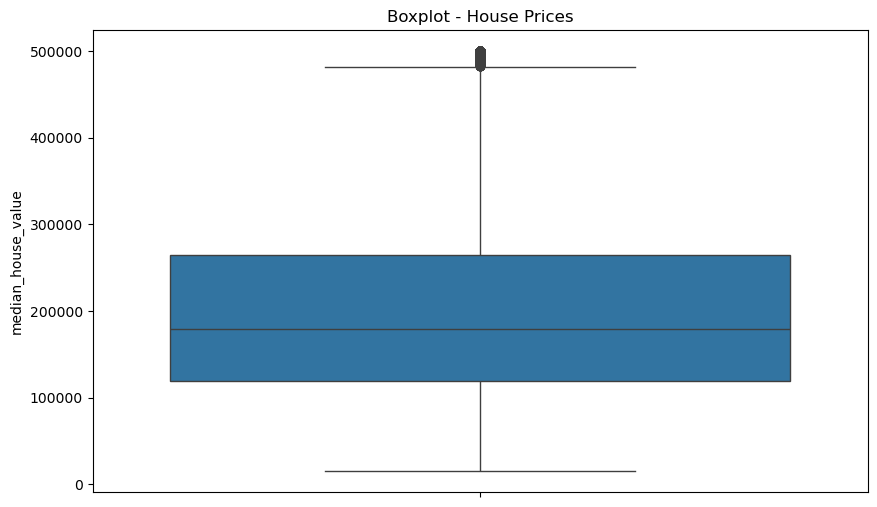

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df["median_house_value"])
plt.title("Boxplot - House Prices")
plt.show()

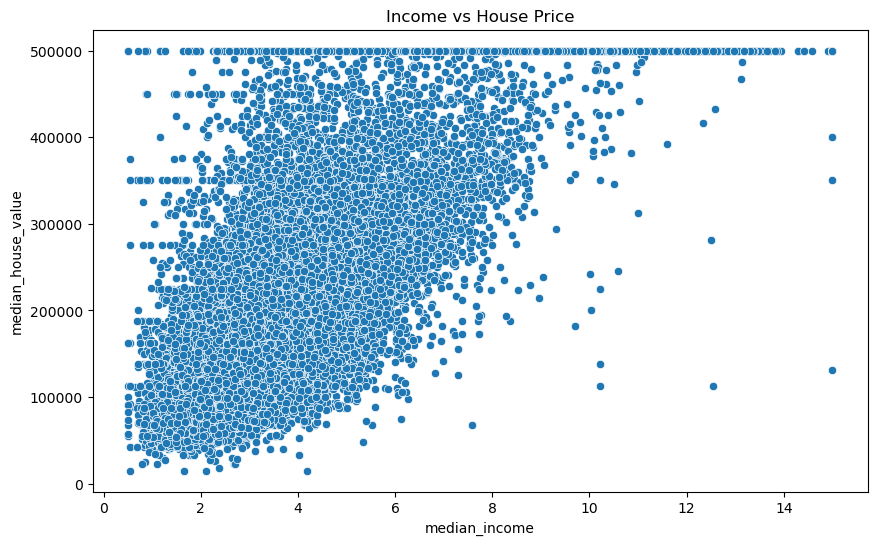

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["median_income"], y=df["median_house_value"])
plt.title("Income vs House Price")
plt.show()

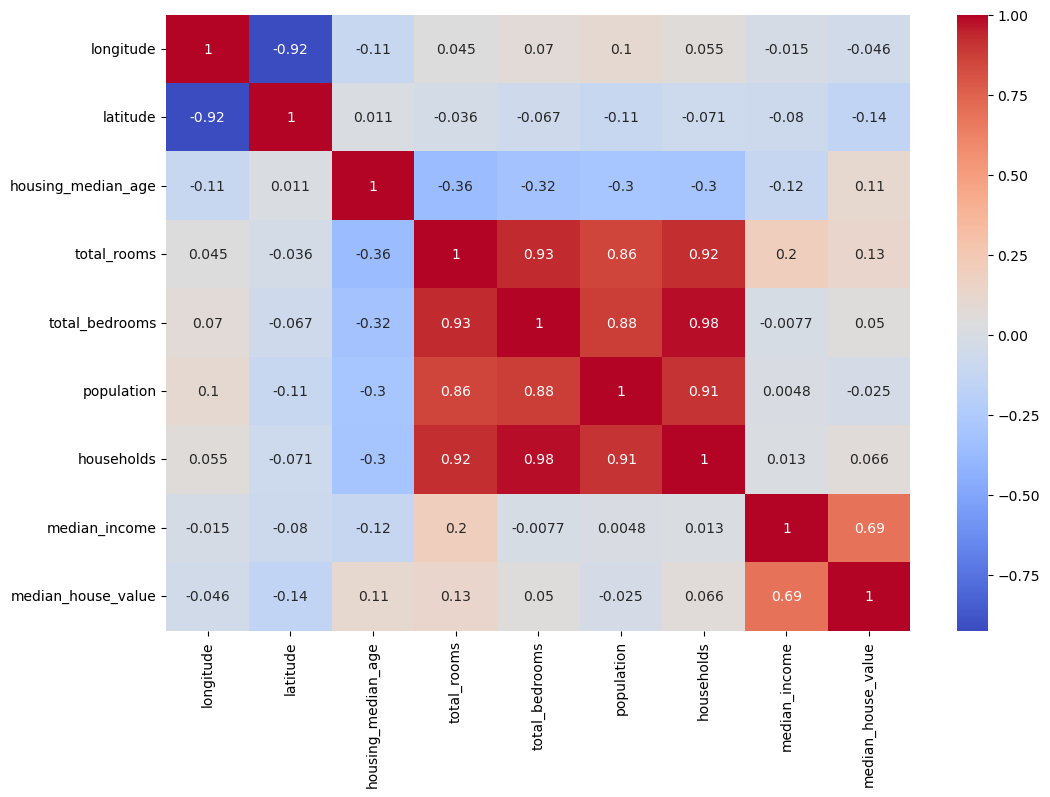

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [ ]:
print("Data shape:", df.shape)

Data shape: (20640, 10)


In [ ]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [ ]:
print("Data shape:", df.shape)

Data shape: (20640, 10)


In [ ]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / (df["total_rooms"] + 1)
df["population_per_household"] = df["population"] / df["households"]
df["income_per_person"] = df["median_income"] / (df["population"] + 1)
df["income_house_ratio"] = df["median_income"] / df["households"]

df["rooms_per_person"] = df["total_rooms"] / (df["population"] + 1)

df["log_population"] = np.log1p(df["population"])
df["log_rooms"] = np.log1p(df["total_rooms"])

print("Features created")
print(df.head())

Features created
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  \
0       322.0       126.0         8.3252            452600.0        NEAR BAY   
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY   
2       496.0       177.0         7.2574            352100.0        NEAR BAY   
3       558.0       219.0         5.6431            341300.0        NEAR BAY   
4       565.0       259.0         3.8462            342200.0        NEAR BAY   

   rooms_per_household  bedrooms_per_room  populati

In [ ]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

print("After encoding:", df.shape)
print(df.columns)

After encoding: (20640, 21)
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household', 'income_per_person', 'income_house_ratio',
       'rooms_per_person', 'log_population', 'log_rooms',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [ ]:
X = df.drop("median_house_value", axis=1)
y = np.log1p(df["median_house_value"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 20)
y shape: (20640,)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling done")
print("Scaled shape:", X_scaled.shape)

Scaling done
Scaled shape: (20640, 20)


In [ ]:
def build_ann():
    model = keras.Sequential([
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='mse'
    )
    return model

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ann_preds = np.zeros(len(X))
xgb_preds = np.zeros(len(X))
cat_preds = np.zeros(len(X))
print("KFold ready")

KFold ready


In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):

    print(f"\n FOLD {fold+1}/5")

    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print("ANN training...")

    ann = build_ann()

    ann.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        verbose=1
    )

    ann_preds[val_idx] = ann.predict(X_val).flatten()

    print("XGBoost training...")

    xgb_model = xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1 
    )

    xgb_model.fit(X.iloc[train_idx], y_train)
    xgb_preds[val_idx] = xgb_model.predict(X.iloc[val_idx])

    print("🐱 CatBoost training")

    cat_model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        verbose=0
    )

    cat_model.fit(X.iloc[train_idx], y_train)
    cat_preds[val_idx] = cat_model.predict(X.iloc[val_idx])


 FOLD 1/5
ANN training...
Epoch 1/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.9167 - val_loss: 0.4803
Epoch 2/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3482 - val_loss: 0.3401
Epoch 3/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2677 - val_loss: 0.2249
Epoch 4/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2269 - val_loss: 0.2669
Epoch 5/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2137 - val_loss: 0.2059
Epoch 6/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1922 - val_loss: 0.2035
Epoch 7/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1986 - val_loss: 0.1627
Epoch 8/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1675 - val_loss: 0.1342
Epoch 9/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1656 - val_loss: 0.1974
Epoch 10/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1589 - val_loss: 0.1917
Epoch 11/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1530 - val_loss: 0.2345
Epoch 12/200
5

In [ ]:
stack = np.column_stack((ann_preds, xgb_preds, cat_preds))

meta = Ridge(alpha=3.0)
meta.fit(stack, y)

final_pred = meta.predict(stack)


In [ ]:
stack = np.column_stack((ann_preds, xgb_preds, cat_preds))

meta = Ridge(alpha=3.0)
meta.fit(stack, y)

final_pred = meta.predict(stack)


In [ ]:
y_real = np.expm1(y)
pred_real = np.expm1(final_pred)

mae = mean_absolute_error(y_real, pred_real)
mse = mean_squared_error(y_real, pred_real)
r2 = r2_score(y_real, pred_real)

print("\n FINAL PERFORMANCE")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)
print("Accuracy %:", r2 * 100)


 FINAL PERFORMANCE
MAE: 28327.01599208821
MSE: 2018638128.8813665
R2: 0.848399408662418
Accuracy %: 84.8399408662418


In [ ]:
result = pd.DataFrame({
    "Real Price": y_real,
    "Predicted Price": pred_real
})

result["Error"] = abs(result["Real Price"] - result["Predicted Price"])

result["Score"] = np.exp(-result["Error"] / 50000)

result["Rank"] = result["Score"].rank(ascending=False)

top10 = result.sort_values("Score", ascending=False).head(10)

print("\n TOP 10 BEST HOUSES")
print(top10)


 TOP 10 BEST HOUSES
       Real Price  Predicted Price     Error     Score  Rank
8436     245600.0    245599.695254  0.304746  0.999994   1.0
1100      95300.0     95299.539573  0.460427  0.999991   2.0
12291     73200.0     73200.713874  0.713874  0.999986   3.0
15518    156800.0    156799.244631  0.755369  0.999985   4.0
17779    209900.0    209898.991754  1.008246  0.999980   5.0
9881     162200.0    162198.751550  1.248450  0.999975   6.0
8884     500001.0    499998.662811  2.337189  0.999953   7.0
4488     142800.0    142802.626383  2.626383  0.999947   8.0
1665     205100.0    205106.674920  6.674920  0.999867   9.0
15484    172600.0    172592.884860  7.115140  0.999858  10.0


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
def recommend_houses(user_input, X, result, top_n=10):

    print("\n Generating improved recommendations...")

    user_df = pd.DataFrame([user_input])
    user_df = pd.get_dummies(user_df)
    user_df = user_df.reindex(columns=X.columns, fill_value=0)

    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics.pairwise import cosine_similarity

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    user_scaled = scaler.transform(user_df)

    sim = cosine_similarity(user_scaled, X_scaled).flatten()

    result = result.copy()
    if "Error" not in result.columns:
        result["Error"] = abs(result["Real Price"] - result["Predicted Price"])

    sim = (sim - sim.min()) / (sim.max() - sim.min() + 1e-8)

    model_score = result["Score"].values
    model_score = (model_score - model_score.min()) / (model_score.max() - model_score.min() + 1e-8)

    error_score = 1 - (result["Error"] / result["Error"].max())

    final_score = (
        0.45 * sim +
        0.35 * model_score +
        0.20 * error_score
    )

    rec = result.copy()
    rec["User_Score"] = sim
    rec["Final_Score"] = final_score

    rec = rec.sort_values("Final_Score", ascending=False).head(top_n)

    return rec[[
        "Real Price",
        "Predicted Price",
        "Score",
        "User_Score",
        "Final_Score"
    ]]

In [ ]:
user_input = {
    "longitude": -122,
    "latitude": 37,
    "housing_median_age": 20,
    "total_rooms": 5000,
    "total_bedrooms": 900,
    "population": 2500,
    "households": 800,
    "median_income": 5,
    "ocean_proximity_INLAND": 1
}

In [ ]:
recommendations = recommend_houses(user_input, X, result)
print(recommendations)


 Generating improved recommendations...
       Real Price  Predicted Price     Score  User_Score  Final_Score
1247      75000.0     75301.854955  0.993981    0.897075     0.951426
12649     80000.0     83665.826044  0.929307    0.950558     0.951143
17522    200000.0    197219.989617  0.945917    0.933760     0.949849
9231      95800.0     97273.585383  0.970958    0.902617     0.945265
20620    100000.0     96675.553217  0.935673    0.930586     0.944558
11892    112500.0    109076.843784  0.933828    0.931427     0.944240
11992    137500.0    137654.111062  0.996923    0.877706     0.943814
19424    131300.0    136034.581580  0.909653    0.944357     0.940931
2898      67500.0     64697.031141  0.945483    0.913450     0.940546
11254    162500.0    165554.834306  0.940732    0.917255     0.940468


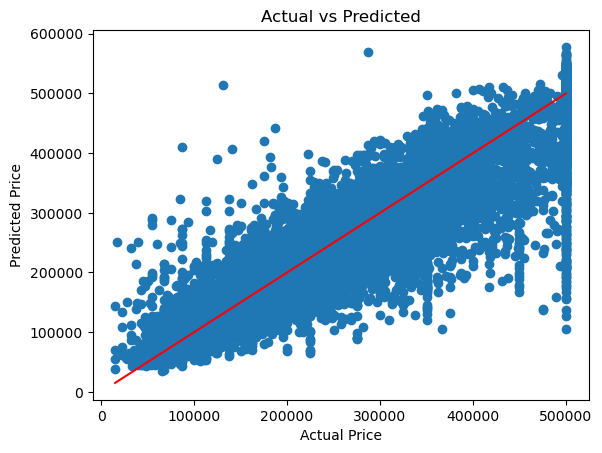

In [ ]:
y_real = np.expm1(y)
pred_real = np.expm1(final_pred)

plt.scatter(y_real, pred_real)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

x = np.linspace(min(y_real), max(y_real), 100)
plt.plot(x, x, color='red')

plt.show()